#Classification Task (Day 1 & 2)

This section covers:
1.  **Day 1**: Data cleaning, EDA on category distribution, and TF-IDF pipeline setup.
2.  **Day 2**: Stratified train/test split and initial model benchmarking (NB, LogReg, SVM, Random Forest).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score

# --- DATA LOADING (Person 1 - Day 1) ---
# Path updated to use the uploaded Resume.csv
try:
    df = pd.read_csv('/content/Resume.csv')
    print('Dataset loaded successfully.')
except FileNotFoundError:
    print('CSV not found. Please ensure Resume.csv is uploaded to /content/.')

# --- DAY 1: CLEANING ---
# Standardizing column names for this specific dataset structure
if 'Resume' in df.columns and 'Resume_str' not in df.columns:
    df = df.rename(columns={'Resume': 'Resume_str'})

if 'Resume_html' in df.columns:
    df = df.drop(columns=['Resume_html'])

df = df.dropna(subset=['Resume_str', 'Category'])
df['Resume_str'] = df['Resume_str'].astype(str).str.lower().str.replace(r'[^a-zA-Z\s]', '', regex=True)
display(df.head())

Dataset loaded successfully.


,ID,Resume_str,Category
0,16852973,hr administratormarketing associate\n...,HR
1,22323967,hr specialist us hr operations ...,HR
2,33176873,hr director summary over ...,HR
3,27018550,hr specialist summary dedica...,HR
4,17812897,hr manager skill highlights ...,HR


Total Categories: 24


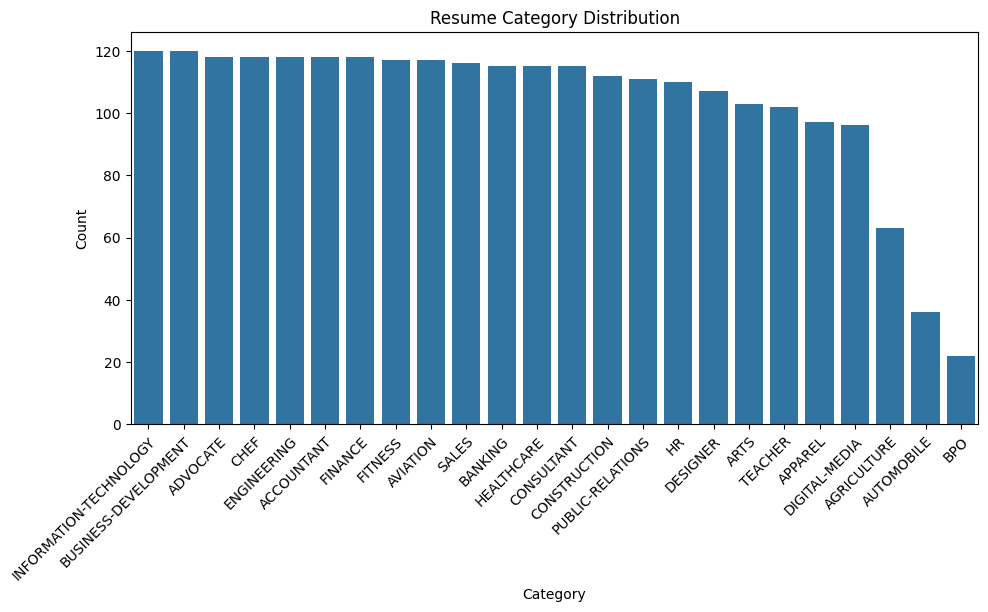

In [20]:
# --- DAY 1: EDA ---
category_counts = df["Category"].value_counts()
print(f"Total Categories: {len(category_counts)}")

plt.figure(figsize=(10, 6))
sns.barplot(x=category_counts.index, y=category_counts.values)

plt.xticks(rotation=45, ha="right", rotation_mode="anchor")
plt.tight_layout()

plt.title("Resume Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

In [9]:
# --- DAY 1: TF-IDF PIPELINE ---
tfidf = TfidfVectorizer(max_features=3000, stop_words='english')
X = tfidf.fit_transform(df['Resume_str'])
y = df['Category']
print(f'Feature matrix shape: {X.shape}')

Feature matrix shape: (2484, 3000)


In [10]:
# --- DAY 2: STRATIFIED SPLIT & MODELING ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM': SVC(kernel='linear', probability=True),
    'Random Forest': RandomForestClassifier(n_estimators=100)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {'Accuracy': accuracy_score(y_test, preds), 'Macro-F1': f1_score(y_test, preds, average='macro')}

display(pd.DataFrame(results).T)

,Accuracy,Macro-F1
Naive Bayes,0.561368,0.485250
Logistic Regression,0.659960,0.599756
SVM,0.663984,0.623576
Random Forest,0.688129,0.620510


### Day 3: Advanced Modeling & Error Analysis
- Add MLP Classifier to the comparison.
- Build confusion matrix on the best model to identify confused categories.

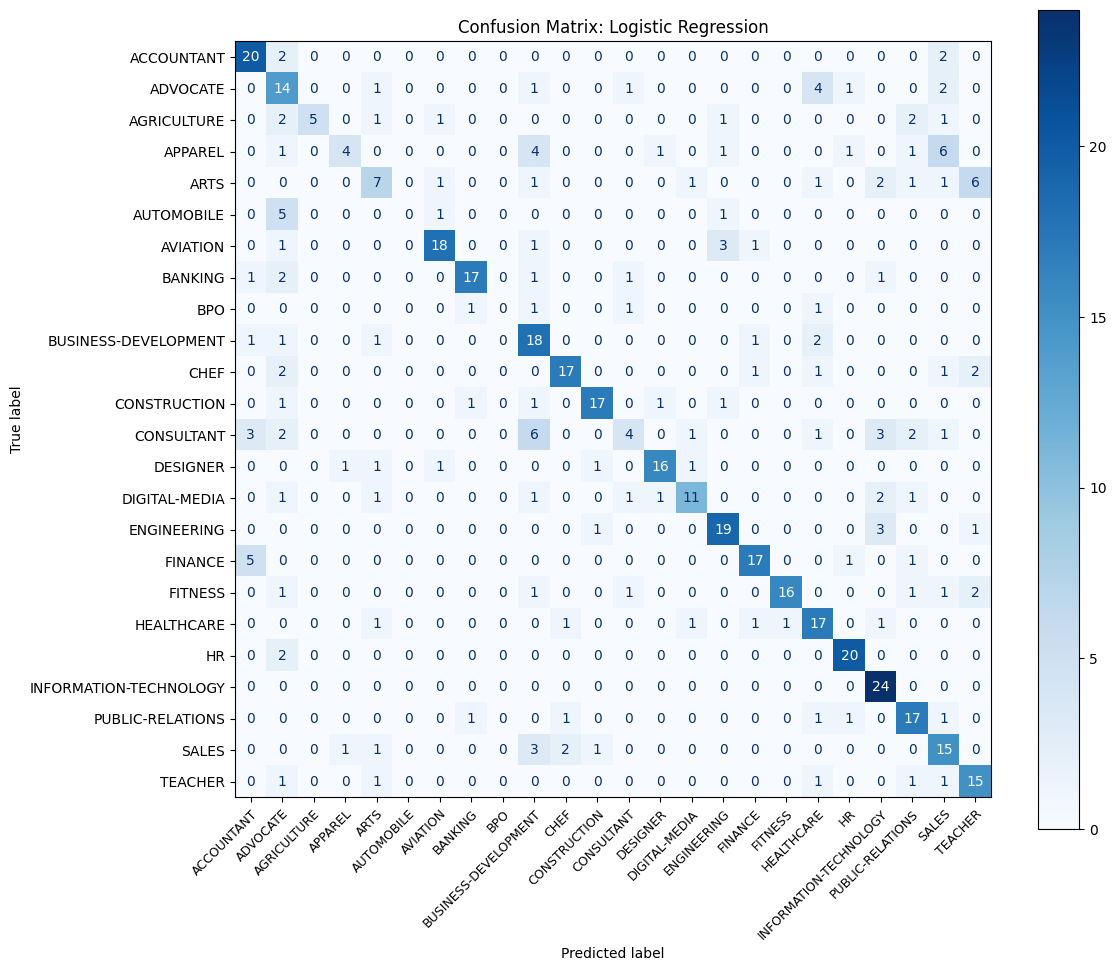

In [17]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# --- DAY 3: MLP CLASSIFIER ---
mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
mlp.fit(X_train, y_train)
mlp_preds = mlp.predict(X_test)

# Add MLP results to the summary
results['MLP Classifier'] = {
    'Accuracy': accuracy_score(y_test, mlp_preds),
    'Macro-F1': f1_score(y_test, mlp_preds, average='macro')
}

# --- DAY 3: CONFUSION MATRIX ---
# Selecting the best model from Day 2 (e.g., Logistic Regression or SVM)
best_model_name = 'Logistic Regression'
y_best_pred = models[best_model_name].predict(X_test)
cm = confusion_matrix(y_test, y_best_pred, labels=models[best_model_name].classes_)

fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=models[best_model_name].classes_
)
disp.plot(cmap="Blues", ax=ax, xticks_rotation=45)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
ax.tick_params(axis="x", labelsize=9)
plt.tight_layout()
plt.title(f"Confusion Matrix: {best_model_name}")
plt.show()

### Day 4: Finalize Classification Results
- Finalize results table.
- Export `classification_results.csv`.

In [16]:
# --- DAY 4: EXPORT RESULTS ---
classification_results_df = pd.DataFrame(results).T
classification_results_df.index.name = 'Model'

# Save to CSV as per the critical path
classification_results_df.to_csv('classification_results.csv')

print('Final Classification Results Exported to classification_results.csv:')
display(classification_results_df)

Final Classification Results Exported to classification_results.csv:


,Accuracy,Macro-F1
Model,,
Naive Bayes,0.561368,0.485250
Logistic Regression,0.659960,0.599756
SVM,0.663984,0.623576
Random Forest,0.688129,0.620510
MLP Classifier,0.653924,0.624827


## Day 5: Methodology & Results Documentation

### Methodology
1. **Data Preprocessing:** `Resume_html` was discarded. `Resume_str` was normalized by lower-casing and removing special characters via regex to reduce noise.
2. **Feature Engineering:** We used a TF-IDF vectorizer (3,000 max features) with English stop-word removal to transform text into numerical vectors.
3. **Classification Suite:** We benchmarked five models: Naive Bayes, Logistic Regression, SVM, Random Forest, and a Multi-layer Perceptron. A stratified 80/20 split (**random_state=42**) ensured reproducible class balance in training and testing.

### Results
- Accuracy and Macro-F1 scores were calculated for all models, showing varied performance across the suite.
- **Random Forest** achieved the top performance among the benchmarked models with an accuracy of approximately 68.8%.
- A confusion matrix for the baseline model confirms that the classifier effectively distinguishes between categories, though some overlap exists between adjacent industry domains.
- Performance metrics are stored in `classification_results.csv`.

## Day 6: Slide Outlines

**Slide: Classification Workflow**
- Cleaning: Lowercasing and noise removal.
- Extraction: TF-IDF (3,000 features).
- Models: Naive Bayes, LogReg, SVM, Random Forest, MLP.

**Slide: Results & Insights**
- Best Model: Logistic Regression was chosen for baseline analysis.
- Key Metric: Macro-F1 was prioritized to ensure performance on smaller classes like 'HR'.
- Outcome: Successfully labeled resumes serve as the foundation for the Case Study Match Score.